# WISDM Dataset 기반 CBAM 분류

In [1]:
# 라이브러리 import
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, BatchNormalization, ReLU,
    MaxPooling1D, GlobalAveragePooling1D, GlobalMaxPooling1D,
    Dense, Dropout, Concatenate, GaussianNoise,
    Multiply, Reshape
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
# 구글 드라이브 연결
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# 경로 정의
DATASET_PATH = "/content/drive/MyDrive/WISDM_ar_v1.1_raw.txt"

## 데이터 전처리

1. **raw 데이터 로드**
2. **클린업** : 마지막 NaN 컬럼 제거, 결측 행 dropna, z_axis의 `;` 제거 후 float 변환
3. **Label Encoding** : LabelEncoder로 activity → 정수
4. **Data Split (user_id 기반)** :
  - user_id ≤ 26 → train set
  - 27 ≤ user_id ≤ 31 → validation set
  - user_id ≥ 32 → test set
5. **정규화** : StandardScaler를 train에서 fit, val/test는 transform만
6. **Segmentation** : sliding window (TIME_STEPS=200, STEP=40)

In [4]:
# raw 데이터 로드
names = ["user_id", "activity", "timestamp", "x_axis", "y_axis", "z_axis", "NaN"]
data = pd.read_csv(DATASET_PATH, header=None, names=names, comment=";")
print(data.head())

   user_id activity       timestamp    x_axis     y_axis    z_axis  NaN
0       33  Jogging  49105962326000 -0.694638  12.680544  0.503953  NaN
1       33  Jogging  49106062271000  5.012288  11.264028  0.953424  NaN
2       33  Jogging  49106112167000  4.903325  10.882658 -0.081722  NaN
3       33  Jogging  49106222305000 -0.612916  18.496431  3.023717  NaN
4       33  Jogging  49106332290000 -1.184970  12.108489  7.205164  NaN


In [5]:
# 클린업
def convert_to_float(x):
    try:
        return np.float32(x)
    except:
        return np.nan

df = data.drop('NaN', axis=1)
df = df.dropna()

df["z_axis"] = df["z_axis"].replace(regex=True, to_replace=r';', value=r'')
df["x_axis"] = df["x_axis"].apply(convert_to_float)
df["y_axis"] = df["y_axis"].apply(convert_to_float)
df["z_axis"] = df["z_axis"].apply(convert_to_float)
df = df.dropna()
df.info()

print("\nActivity counts:")
print(df['activity'].value_counts())

<class 'pandas.core.frame.DataFrame'>
Index: 1098203 entries, 0 to 1098203
Data columns (total 6 columns):
 #   Column     Non-Null Count    Dtype  
---  ------     --------------    -----  
 0   user_id    1098203 non-null  int64  
 1   activity   1098203 non-null  object 
 2   timestamp  1098203 non-null  int64  
 3   x_axis     1098203 non-null  float32
 4   y_axis     1098203 non-null  float32
 5   z_axis     1098203 non-null  float32
dtypes: float32(3), int64(2), object(1)
memory usage: 46.1+ MB

Activity counts:
activity
Walking       424397
Jogging       342176
Upstairs      122869
Downstairs    100427
Sitting        59939
Standing       48395
Name: count, dtype: int64


In [6]:
# Label Encoding
label_encoder = LabelEncoder()
df['activity_encoded'] = label_encoder.fit_transform(df['activity'])
num_classes = len(label_encoder.classes_)
print("\nLabel mapping:", dict(enumerate(label_encoder.classes_)))


Label mapping: {0: 'Downstairs', 1: 'Jogging', 2: 'Sitting', 3: 'Standing', 4: 'Upstairs', 5: 'Walking'}


In [7]:
# Data Split (user_id 기반)
df_train = df[df['user_id'] <= 26]
df_val   = df[(df['user_id'] > 26) & (df['user_id'] < 32)]
df_test  = df[df['user_id'] >= 32]

print(f"\nTrain users: {sorted(df_train['user_id'].unique())}")
print(f"Val   users: {sorted(df_val['user_id'].unique())}")
print(f"Test  users: {sorted(df_test['user_id'].unique())}")


Train users: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26)]
Val   users: [np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31)]
Test  users: [np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36)]


In [8]:
# 정규화
scaler = StandardScaler()
df_train.loc[:, ['x_axis', 'y_axis', 'z_axis']] = scaler.fit_transform(df_train.loc[:, ['x_axis', 'y_axis', 'z_axis']])
df_val.loc[:,   ['x_axis', 'y_axis', 'z_axis']] = scaler.transform(df_val.loc[:,   ['x_axis', 'y_axis', 'z_axis']])
df_test.loc[:,  ['x_axis', 'y_axis', 'z_axis']] = scaler.transform(df_test.loc[:,  ['x_axis', 'y_axis', 'z_axis']])

In [9]:
# Segmentation (Sliding Window)
def create_dataset(x, y, time_steps=200, step=40):
    xs, ys = [], []
    for i in range(0, len(x) - time_steps, step):
        v = x.iloc[i:i + time_steps].values
        labels = y.iloc[i:i + time_steps]
        values, counts = np.unique(labels, return_counts=True)
        mode_label = values[np.argmax(counts)]
        xs.append(v)
        ys.append(mode_label)
    return np.array(xs), np.array(ys)

TIME_STEPS = 200
STEP = 40
x_train, y_train = create_dataset(df_train[['x_axis', 'y_axis', 'z_axis']], df_train['activity_encoded'], TIME_STEPS, STEP)
x_val,   y_val   = create_dataset(df_val[['x_axis', 'y_axis', 'z_axis']],   df_val['activity_encoded'],   TIME_STEPS, STEP)
x_test,  y_test  = create_dataset(df_test[['x_axis', 'y_axis', 'z_axis']],  df_test['activity_encoded'],  TIME_STEPS, STEP)

print(f"\nx_train: {x_train.shape}, y_train: {y_train.shape}")
print(f"x_val  : {x_val.shape},  y_val  : {y_val.shape}")
print(f"x_test : {x_test.shape},  y_test : {y_test.shape}")


x_train: (19457, 200, 3), y_train: (19457,)
x_val  : (4100, 200, 3),  y_val  : (4100,)
x_test : (3885, 200, 3),  y_test : (3885,)


In [10]:
# 클래스 가중치 (불균형 보정)
weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = dict(enumerate(weights))
print("Class weights:", class_weights_dict)

Class weights: {0: np.float64(1.899726615895333), 1: np.float64(0.5175284604745186), 2: np.float64(3.272283888328288), 3: np.float64(4.244546247818499), 4: np.float64(1.4834553217444342), 5: np.float64(0.429912943567988)}


## CBAM (Convolutional Block Attention Module)

CBAM은 **채널 어텐션 → 공간(시간) 어텐션**을 순서대로 적용하는 어텐션 구조

SE Block이 채널만 봤다면, CBAM은 **어떤 채널이 중요한가** 와 **어느 시간 구간이 중요한가** 를 둘 다 학습

---

### Step 1 : Channel Attention (채널 어텐션)

1. **특징 추출**: 입력된 특징 맵을 시간 방향으로 **Max Pooling**과 **GAP(Global Average Pooling)**를 각각 수행

    → 채널의 핵심 정보와 전반적인 통계 정보를 동시에 추출

2. **공유 MLP 통과**: 추출된 두 벡터는 가중치를 공유하는 MLP(Shared MLP)를 통과

    → **ReLU 함수**로 비선형성을 부여해 복잡한 채널 간의 관계를 학습

3. **스코어 생성**: MLP를 통과한 두 결과물을 원소별 합(Element-wise Sum)으로 결합

    → **시그모이드(Sigmoid)** 함수를 거쳐 0과 1 사이의 **채널 어텐션 스코어**를 도출

4. **최종 필터링(Scaling)**: 계산된 스코어 벡터를 원본 특징 맵에 채널별로 곱함

    → 유의미한 채널은 강조되고, 불필요한 노이즈 채널은 억제

---

### Step 2 : Spatial Attention (공간/시간 어텐션)

1. **채널 축 기준 정보 압축**: 채널 축을 기준으로 **Max Pooling과 Average Pooling을 각각 수행**

2. **2채널 블록 형성 (Concatenation)**: 추출된 두 맵을 합쳐(Concat) **2채널 압축 특징 블록**을 만듦

3. **시간 연관성 학습 (Spatial Convolution)**: 이 2채널 맵 위로 **커널 크기 7의 Conv1D**를 적용

    → 제로 패딩으로 시간 해상도를 유지하고, 채널 수만 1로 줄여 **시간 중요도 맵**을 도출

4. **확률 변환 및 최종 적용**: **시그모이드** 적용 후 채널 어텐션 출력에 원소별로 곱함

---

### CBAM 전체 흐름
Conv 출력 → Channel Attention → Spatial Attention → 최종 출력

In [11]:
# Channel Attention 정의
def channel_attention(x, ratio=8):
    channels = x.shape[-1]
    reduction = max(channels // ratio, 1)

    # 시간 축 전체를 평균/최대로 압축 -> (batch, channels)
    avg_pool = GlobalAveragePooling1D()(x)
    max_pool = GlobalMaxPooling1D()(x)

    # 두 통계를 같은 MLP에 통과 (가중치 공유)
    shared_dense1 = Dense(reduction, activation='relu', use_bias=False)
    shared_dense2 = Dense(channels,  activation=None,   use_bias=False)

    avg_out = shared_dense2(shared_dense1(avg_pool))
    max_out = shared_dense2(shared_dense1(max_pool))

    # 두 결과를 더한 뒤 sigmoid로 채널별 가중치 생성
    scale = tf.keras.activations.sigmoid(avg_out + max_out)  # (batch, channels)
    scale = Reshape((1, channels))(scale)                    # (batch, 1, channels)

    return Multiply()([x, scale])

In [12]:
# Spatial Attention 정의
def spatial_attention(x, kernel_size=7):
    # 채널 방향을 1×1 Conv로 압축 -> (batch, time, 1) 각각 학습
    avg_pool = Conv1D(1, kernel_size=1, use_bias=False)(x)
    max_pool = Conv1D(1, kernel_size=1, use_bias=False)(x)

    # 채널 방향으로 합침 -> (batch, time, 2)
    concat = Concatenate(axis=-1)([avg_pool, max_pool])

    # Conv1D로 시간 위치별 가중치 학습 -> (batch, time, 1)
    scale = Conv1D(1, kernel_size=kernel_size, padding='same',
                   activation='sigmoid', use_bias=False)(concat)

    return Multiply()([x, scale])

In [13]:
# CBAM Block 정의: 채널 어텐션 -> 공간(시간) 어텐션 순서로 적용
def cbam_block(x, ratio=8, kernel_size=7):
    x = channel_attention(x, ratio=ratio)
    x = spatial_attention(x, kernel_size=kernel_size)
    return x

## Conv-CBAM Block
두 번의 Conv 연산으로 시간 패턴을 추출한 뒤, CBAM으로 채널 → 시간 어텐션을 순서대로 적용

In [14]:
# Conv-CBAM Block 정의
def conv_cbam_block(x, filters, kernel_size=3, pool=True, ratio=8, attn_kernel=7):
    # 첫 번째 Conv: 기본적인 시간 패턴 추출
    x = Conv1D(filters, kernel_size=kernel_size, padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    # 두 번째 Conv: 더 복잡한 특징 학습
    x = Conv1D(filters, kernel_size=kernel_size, padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    # CBAM: 채널 어텐션 -> 공간(시간) 어텐션
    x = cbam_block(x, ratio=ratio, kernel_size=attn_kernel)

    if pool:
        x = MaxPooling1D(pool_size=2)(x)

    return x

In [15]:
# CBAM 모델 정의
def build_cbam_model(input_shape, num_classes):
    inputs = Input(shape=input_shape)

    # 약한 노이즈: 과적합 방지
    x = GaussianNoise(0.01)(inputs)

    # 초기 특징 추출 (WISDM은 TIME_STEPS=200으로 길어 kernel_size=7 사용)
    x = Conv1D(64, kernel_size=7, padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = MaxPooling1D(pool_size=2)(x)  # 200 -> 100

    # Conv-CBAM Blocks
    x = conv_cbam_block(x, filters=64,  kernel_size=3, pool=True,  ratio=8, attn_kernel=7)
    x = conv_cbam_block(x, filters=128, kernel_size=3, pool=True,  ratio=8, attn_kernel=7)
    x = conv_cbam_block(x, filters=256, kernel_size=3, pool=True,  ratio=8, attn_kernel=7)
    x = conv_cbam_block(x, filters=256, kernel_size=5, pool=False, ratio=8, attn_kernel=7)

    # 평균 + 최대 pooling 병합
    avg_pool = GlobalAveragePooling1D()(x)
    max_pool = GlobalMaxPooling1D()(x)
    x = Concatenate()([avg_pool, max_pool])  # (batch, 512)

    # 분류 헤드
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.4)(x)

    outputs = Dense(num_classes, activation='softmax')(x)

    return Model(inputs, outputs)

In [16]:
# 모델 생성 및 컴파일
input_shape = (x_train.shape[1], x_train.shape[2])  # (200, 3)
num_classes = len(label_encoder.classes_)

model = build_cbam_model(input_shape, num_classes)

model.compile(
    optimizer=Adam(learning_rate=3e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['sparse_categorical_accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 200, 3)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gaussian_noise      │ (None, 200, 3)    │          0 │ input_layer[0][0] │
│ (GaussianNoise)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 200, 64)   │      1,344 │ gaussian_noise[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 200, 64)   │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 200, 64)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 100, 64)   │          0 │ re_lu[0][0]       │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 100, 64)   │     12,288 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 100, 64)   │        256 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 100, 64)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 100, 64)   │     12,288 │ re_lu_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 100, 64)   │        256 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 100, 64)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ re_lu_2[0][0]     │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 64)        │          0 │ re_lu_2[0][0]     │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 8)         │        512 │ global_average_p… │
│                     │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │        512 │ dense[0][0],      │
│                     │                   │            │ dense[1][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 64)        │          0 │ dense_1[0][0],    │
│                     │                   │            │ dense_1[1][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sigmoid (Sigmoid)   │ (None, 64)        │          0 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 64)     │          0 │ sigmoid[0][0]     │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 1,260,158 (4.81 MB)

 Trainable params: 1,257,214 (4.80 MB)

 Non-trainable params: 2,944 (11.50 KB)

In [17]:
# Callback 설정
callbacks = [
    ModelCheckpoint(
        "WISDM_HAR_CBAM_best.keras",
        monitor="val_sparse_categorical_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=10,
        min_lr=1e-6,
        verbose=1
    ),
    EarlyStopping(
        monitor="val_sparse_categorical_accuracy",
        mode="max",
        patience=20,
        restore_best_weights=True,
        verbose=1
    )
]

In [18]:
# 모델 학습
history = model.fit(
    x_train, y_train,
    epochs=100,
    batch_size=64,
    validation_data=(x_val, y_val),
    callbacks=callbacks,
    class_weight=class_weights_dict,
    shuffle=True,
    verbose=1
)

Epoch 1/100
305/305 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.7503 - sparse_categorical_accuracy: 0.7293
Epoch 1: val_sparse_categorical_accuracy improved from None to 0.22634, saving model to WISDM_HAR_CBAM_best.keras

Epoch 1: finished saving model to WISDM_HAR_CBAM_best.keras
305/305 ━━━━━━━━━━━━━━━━━━━━ 40s 56ms/step - loss: 0.4389 - sparse_categorical_accuracy: 0.8533 - val_loss: 2.9674 - val_sparse_categorical_accuracy: 0.2263 - learning_rate: 3.0000e-04
Epoch 2/100
301/305 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1368 - sparse_categorical_accuracy: 0.9681
Epoch 2: val_sparse_categorical_accuracy improved from 0.22634 to 0.75463, saving model to WISDM_HAR_CBAM_best.keras

Epoch 2: finished saving model to WISDM_HAR_CBAM_best.keras
305/305 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.1183 - sparse_categorical_accuracy: 0.9725 - val_loss: 1.0007 - val_sparse_categorical_accuracy: 0.7546 - learning_rate: 3.0000e-04
Epoch 3/100
303/305 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0

In [19]:
model = tf.keras.models.load_model("WISDM_HAR_CBAM_best.keras")

In [20]:
# 학습 및 테스트 성능 평가
train_loss, train_acc = model.evaluate(x_train, y_train, verbose=0)
test_loss,  test_acc  = model.evaluate(x_test,  y_test,  verbose=0)

print(f"Training accuracy: {train_acc * 100:.2f}%")
print(f"Training loss: {train_loss:.4f}")
print(f"Test accuracy: {test_acc * 100:.2f}%")
print(f"Test loss: {test_loss:.4f}")

Training accuracy: 99.91%
Training loss: 0.0033
Test accuracy: 94.49%
Test loss: 0.3213


In [21]:
# 예측 및 분류 리포트
y_pred_proba = model.predict(x_test, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_, digits=4))


Classification Report:
              precision    recall  f1-score   support

  Downstairs     0.8083    0.9017    0.8525       346
     Jogging     0.9776    0.9620    0.9697      1316
     Sitting     1.0000    0.9967    0.9983       300
    Standing     0.9947    1.0000    0.9974       189
    Upstairs     0.9127    0.7891    0.8464       384
     Walking     0.9414    0.9644    0.9528      1350

    accuracy                         0.9449      3885
   macro avg     0.9391    0.9357    0.9362      3885
weighted avg     0.9461    0.9449    0.9448      3885



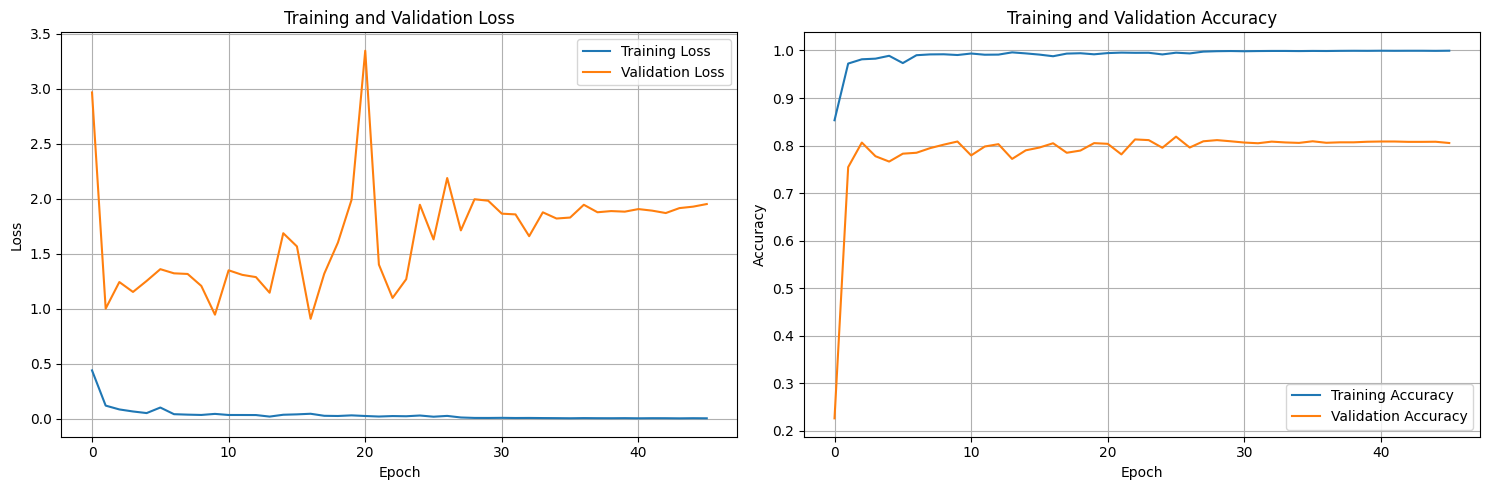

In [22]:
# 학습 곡선 시각화
train_loss_hist = history.history['loss']
val_loss_hist   = history.history['val_loss']
train_acc_hist  = history.history['sparse_categorical_accuracy']
val_acc_hist    = history.history['val_sparse_categorical_accuracy']

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(train_loss_hist, label='Training Loss')
plt.plot(val_loss_hist,   label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_acc_hist, label='Training Accuracy')
plt.plot(val_acc_hist,   label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

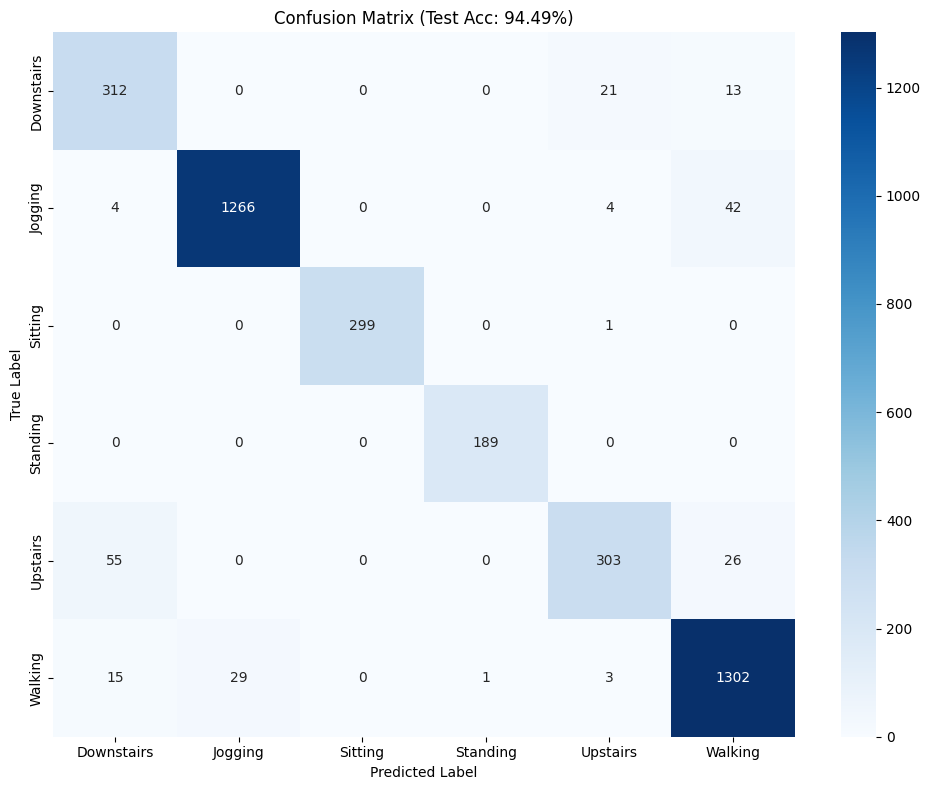

In [23]:
# 혼동 행렬
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title(f'Confusion Matrix (Test Acc: {test_acc * 100:.2f}%)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()